# SingleR reference annotation

Run cells from top to bottom. Paths and thread counts are centralized in `config/`; embedded plots are retained as visual references from the source analysis.


In [ ]:
# Centralized paths and scheduler-aware thread limits.
repo_root <- if (file.exists("config/paths.R")) "." else if (file.exists("../config/paths.R")) ".." else stop("Run Jupyter from the repository root or notebooks/ directory.")
source(file.path(repo_root, "config", "paths.R"))


In [1]:
# =========================================================================
# ========= 脚本顶部的关键配置 (处理缓存路径问题) =========
# (缓存设置代码保持不变)
# =========================================================================
expected_cache_path <- legacy_path("20250519KO-GLH/R_EH_cache")
if (!requireNamespace("BiocFileCache", quietly = TRUE)) stop("BiocFileCache 包未安装.")
suppressPackageStartupMessages(library(BiocFileCache))
actual_bfc_cache <- BiocFileCache::getBFCOption("CACHE")
if (is.null(actual_bfc_cache) || actual_bfc_cache != expected_cache_path) {
    print(paste("BiocFileCache 路径期望为:", expected_cache_path, "但实际为:", actual_bfc_cache, "尝试重新设置..."))
    BiocFileCache::setBFCOption("CACHE", expected_cache_path)
    if (BiocFileCache::getBFCOption("CACHE") != expected_cache_path) options(BIOCFILECACHE_CACHE = expected_cache_path)
}
if (BiocFileCache::getBFCOption("CACHE") == expected_cache_path) {
    print(paste("BiocFileCache 路径已成功设置为:", expected_cache_path))
} else {
    warning(paste("BiocFileCache 路径未能成功设置为:", expected_cache_path, ". 当前为:", BiocFileCache::getBFCOption("CACHE")))
}

# =========================================================================
# ========================== 主要分析代码开始 ===========================
# =========================================================================
print("--- 0. 设置和加载R包 ---")
suppressPackageStartupMessages({
    library(SingleR)
    library(celldex)
    library(Seurat)
    library(dplyr)
    library(ggplot2)
    library(ExperimentHub)
    library(BiocParallel)
})
current_eh_path <- tryCatch(ExperimentHub::getExperimentHubOption("CACHE"), error = function(e) NA_character_)
if (is.na(current_eh_path) || current_eh_path != expected_cache_path) {
    tryCatch({
        ExperimentHub::setExperimentHubOption("CACHE", expected_cache_path)
        if (ExperimentHub::getExperimentHubOption("CACHE") != expected_cache_path) warning("警告: ExperimentHub 路径未能通过 setExperimentHubOption 设置。")
        else print(paste("ExperimentHub 路径已成功设置为:", expected_cache_path))
    }, error = function(e) {
        warning(paste("设置 ExperimentHub 路径失败:", conditionMessage(e), "尝试 options()"))
        options(EXPERIMENT_HUB_CACHE = expected_cache_path)
         if (tryCatch(ExperimentHub::getExperimentHubOption("CACHE"), error = function(e) NA_character_) == expected_cache_path) print(paste("ExperimentHub 路径通过 options() 设置为:", expected_cache_path))
         else warning("ExperimentHub 路径通过 options() 设置也失败了。")
    })
} else {
    print(paste("ExperimentHub 路径已设置为:", current_eh_path))
}

# ------------------- 1. 加载并彻底检查 Seurat 对象 -------------------
print("--- 1. 加载并检查 Seurat 对象 ---")
singlet_data_path <- legacy_path("20250509-doublet-p38/1QC/2stsub.rds")
print(paste("加载Seurat对象从:", singlet_data_path))
singlet_data <- readRDS(singlet_data_path)

print("======== Seurat 对象整体结构 ========")
print(singlet_data)
expected_dims <- c(nrow(singlet_data), ncol(singlet_data))
print(paste("预期维度 (基因 x 细胞):", paste(expected_dims, collapse=" x ")))
# 诊断 expected_dims 类型
print(paste("类型 of expected_dims:", class(expected_dims)))
print(paste("类型 of expected_dims[1]:", class(expected_dims[1])))
print(paste("类型 of expected_dims[2]:", class(expected_dims[2])))


print("======== 深入检查 RNA Assay Layers ========")
if (!"RNA" %in% Assays(singlet_data)) {
    stop("错误: 对象中不存在 'RNA' assay。")
}
rna_assay_obj <- singlet_data[["RNA"]]
print("RNA Assay 中的 Layers:")
print(Layers(rna_assay_obj))

data_layer_matrix <- NULL
counts_layer_matrix <- NULL

# --- 尝试获取 "data" Layer ---
print("---- 尝试获取和检查 'data' Layer ----")
if ("data" %in% Layers(rna_assay_obj)) {
    tryCatch({
        data_layer_matrix <- LayerData(singlet_data, assay = "RNA", layer = "data")
        print("'data' layer 获取成功。")
        current_dims_data <- dim(data_layer_matrix)
        print(paste("维度 of 'data' layer matrix (基因 x 细胞):", paste(current_dims_data, collapse = " x ")))
        # 诊断 current_dims_data 类型
        print(paste("类型 of current_dims_data:", class(current_dims_data)))

        # 修改维度比较方式
        if (!is.null(data_layer_matrix) && length(current_dims_data) == 2 && all(current_dims_data == expected_dims)) {
            print("GOOD: 'data' layer 维度与对象整体维度匹配。")
            # ... (其他检查如前) ...
            if (!identical(colnames(data_layer_matrix), colnames(singlet_data))) warning("警告: 'data' layer 的细胞名与Seurat对象细胞名不匹配。")
            if (!identical(rownames(data_layer_matrix), rownames(singlet_data))) warning("警告: 'data' layer 的基因名与Seurat对象基因名不匹配。")
        } else {
            print(paste("PROBLEM: 'data' layer 维度 (", paste(current_dims_data, collapse=" x "), ") 与对象整体维度 (", paste(expected_dims, collapse=" x "), ") 不匹配或无效。"))
            data_layer_matrix <- NULL
        }
    }, error = function(e) {
        print(paste("获取 'data' layer 时出错:", conditionMessage(e)))
        data_layer_matrix <- NULL
    })
} else {
    print("'data' layer 在 RNA assay 中不存在。")
}

# --- 尝试获取 "counts" Layer ---
print("---- 尝试获取和检查 'counts' Layer ----")
if ("counts" %in% Layers(rna_assay_obj)) {
    tryCatch({
        counts_layer_matrix <- LayerData(singlet_data, assay = "RNA", layer = "counts")
        print("'counts' layer 获取成功。")
        current_dims_counts <- dim(counts_layer_matrix)
        print(paste("维度 of 'counts' layer matrix (基因 x 细胞):", paste(current_dims_counts, collapse = " x ")))
        # 诊断 current_dims_counts 类型
        print(paste("类型 of current_dims_counts:", class(current_dims_counts)))

        # 修改维度比较方式
        if (!is.null(counts_layer_matrix) && length(current_dims_counts) == 2 && all(current_dims_counts == expected_dims)) {
            print("GOOD: 'counts' layer 维度与对象整体维度匹配。")
            # ... (其他检查如前) ...
            if (!identical(colnames(counts_layer_matrix), colnames(singlet_data))) warning("警告: 'counts' layer 的细胞名与Seurat对象细胞名不匹配。")
            if (!identical(rownames(counts_layer_matrix), rownames(singlet_data))) warning("警告: 'counts' layer 的基因名与Seurat对象基因名不匹配。")
        } else {
            print(paste("PROBLEM: 'counts' layer 维度 (", paste(current_dims_counts, collapse=" x "), ") 与对象整体维度 (", paste(expected_dims, collapse=" x "), ") 不匹配或无效。"))
            counts_layer_matrix <- NULL
        }
    }, error = function(e) {
        print(paste("获取 'counts' layer 时出错:", conditionMessage(e)))
        counts_layer_matrix <- NULL
    })
} else {
    print("'counts' layer 在 RNA assay 中不存在。")
}


# ------------------- 2. 决定并准备SingleR输入矩阵 -------------------
print("--- 2. 决定并准备SingleR输入矩阵 ---")
mat_for_singler <- NULL

# 优先使用 'data' layer 如果它有效
if (!is.null(data_layer_matrix)) {
    # 再次确认行列名是否与主对象匹配
    if (identical(colnames(data_layer_matrix), colnames(singlet_data)) && identical(rownames(data_layer_matrix), rownames(singlet_data))) {
        print("策略1: 'data' layer 可用、维度正确且行列名匹配，将直接使用它。")
        mat_for_singler <- data_layer_matrix
    } else {
        warning("尽管 'data' layer 维度正确，但其行名/列名与主对象不完全匹配。将尝试从counts layer重新生成。")
        data_layer_matrix <- NULL # 标记data_layer_matrix为不可用，以便尝试counts
    }
}

# 如果 'data' layer 不可用或不合适，则尝试 'counts' layer
if (is.null(mat_for_singler) && !is.null(counts_layer_matrix)) {
    # 再次确认行列名是否与主对象匹配
    if (identical(colnames(counts_layer_matrix), colnames(singlet_data)) && identical(rownames(counts_layer_matrix), rownames(singlet_data))) {
        print("策略2: 'data' layer 不可用或不合适。将从 'counts' layer 开始并进行归一化。")
        print("创建临时Seurat对象并进行LogNormalize...")
        temp_seurat <- CreateSeuratObject(counts = counts_layer_matrix,
                                          assay = "TEMP_RNA",
                                          project = "TempForSingleR",
                                          meta.data = singlet_data[[]])
        temp_seurat <- NormalizeData(temp_seurat, assay = "TEMP_RNA",
                                     normalization.method = "LogNormalize", scale.factor = 10000,
                                     verbose = FALSE)
        mat_for_singler <- LayerData(temp_seurat, assay = "TEMP_RNA", layer = "data")
        rm(temp_seurat); gc()
        print("从 'counts' layer 归一化得到的矩阵已准备好。")
    } else {
         warning("'counts' layer 维度正确，但其行名/列名与主对象不完全匹配。无法安全使用。")
         counts_layer_matrix <- NULL # 标记counts_layer_matrix为不可用
    }
}

if (is.null(mat_for_singler)) {
    stop("致命错误: 无法为SingleR准备有效的输入矩阵。'data' layer 和 'counts' layer 都有问题(维度或行列名不匹配)或不存在。")
}

# ---- 最终诊断 'mat_for_singler' ----
print("---- DIAGNOSTICS FOR 'mat_for_singler' (final input to SingleR) ----")
# ... (这部分诊断代码不变) ...
print("Dimensions of mat_for_singler (genes x cells):")
print(dim(mat_for_singler))
print("First 5 colnames of mat_for_singler (cell names):")
print(head(colnames(mat_for_singler), 5))
print("First 5 rownames of mat_for_singler (gene names):")
print(head(rownames(mat_for_singler), 5))
if (!identical(colnames(mat_for_singler), colnames(singlet_data))) {
    warning("CRITICAL WARNING: Final 'mat_for_singler' cell names DO NOT MATCH original Seurat object cell names.")
}
if (!identical(rownames(mat_for_singler), rownames(singlet_data))) {
    warning("CRITICAL WARNING: Final 'mat_for_singler' gene names DO NOT MATCH original Seurat object gene names.")
}
print("--------------------------------------")


# ------------------- 3. 加载SingleR参考集并执行注释 -------------------
# ... (后续代码不变) ...
print("--- 3. 加载SingleR参考集并执行注释 ---")
print("加载ImmGen参考数据集...")
ref <- celldex::ImmGenData()
print("ImmGen参考集加载完成.")

print("运行SingleR (使用SerialParam)...")
if (!is.matrix(mat_for_singler) && !inherits(mat_for_singler, "Matrix")) {
    warning("'mat_for_singler' is not a matrix or Matrix object. Converting to matrix.")
    mat_for_singler <- as.matrix(mat_for_singler)
}
if (is.null(colnames(mat_for_singler)) || any(is.na(colnames(mat_for_singler))) || any(duplicated(colnames(mat_for_singler)))) {
    stop("错误: SingleR的最终输入矩阵 'mat_for_singler' 的列名 (细胞名) 存在问题 (NULL, NA, or duplicates).")
}
if (is.null(rownames(mat_for_singler)) || any(is.na(rownames(mat_for_singler))) || any(duplicated(rownames(mat_for_singler)))) {
    stop("错误: SingleR的最终输入矩阵 'mat_for_singler' 的行名 (基因名) 存在问题 (NULL, NA, or duplicates).")
}

pred.immgen.fine <- SingleR(test = mat_for_singler,
                            ref = ref,
                            labels = ref$label.fine,
                            BPPARAM = BiocParallel::SerialParam())
print("SingleR注释完成.")

# ---- 诊断 'pred.immgen.fine' ----
print("---- DIAGNOSTICS FOR 'pred.immgen.fine' ----")
print(paste("Class:", class(pred.immgen.fine)))
print(paste("Dimensions (expected cells x annotations):", paste(dim(pred.immgen.fine), collapse=" x ")))
print("First 5 rownames (expected cell names):"); print(head(rownames(pred.immgen.fine), 5))
if (is.null(rownames(pred.immgen.fine)) || all(is.na(rownames(pred.immgen.fine)))) {
    stop("CRITICAL ERROR: SingleR output 'pred.immgen.fine' has no valid rownames (cell names).")
}
if (nrow(pred.immgen.fine) != ncol(mat_for_singler)) {
    stop(paste0("CRITICAL ERROR: SingleR output 'pred.immgen.fine' row count (", nrow(pred.immgen.fine),
               ") does not match input matrix cell count (", ncol(mat_for_singler), "). Possible gene/cell confusion in SingleR." ))
}
if (!identical(rownames(pred.immgen.fine), colnames(mat_for_singler))) {
    warning("WARNING: Rownames of 'pred.immgen.fine' (SingleR output) DO NOT perfectly MATCH colnames of 'mat_for_singler' (SingleR input). Check for order or subset issues.")
} else {
    print("GOOD: Rownames of 'pred.immgen.fine' perfectly match colnames of 'mat_for_singler'.")
}
print("--------------------------------------")

# ------------------- 4. 将结果添加到Seurat对象 -------------------
# ... (后续代码不变) ...
print("--- 4. 将结果添加到Seurat对象 ---")
singlet_data$pred.immgen.fine <- NA_character_
singlet_data$pred.immgen.fine.pruned <- NA_character_

common_cells <- intersect(colnames(singlet_data), rownames(pred.immgen.fine))
if (length(common_cells) > 0) {
    print(paste("Found", length(common_cells), "common cells for annotation."))
    
    pred_labels_common <- pred.immgen.fine[common_cells, "labels", drop = FALSE]
    singlet_data$pred.immgen.fine[match(common_cells, colnames(singlet_data))] <- pred_labels_common[,1]

    if ("pruned.labels" %in% colnames(pred.immgen.fine)) {
        pred_pruned_common <- pred.immgen.fine[common_cells, "pruned.labels", drop = FALSE]
        singlet_data$pred.immgen.fine.pruned[match(common_cells, colnames(singlet_data))] <- pred_pruned_common[,1]
    } else if (!is.null(pred.immgen.fine$pruned.labels) && length(pred.immgen.fine$pruned.labels) == nrow(pred.immgen.fine)) {
        temp_pruned_all <- pred.immgen.fine$pruned.labels
        names(temp_pruned_all) <- rownames(pred.immgen.fine)
        singlet_data$pred.immgen.fine.pruned[match(common_cells, colnames(singlet_data))] <- temp_pruned_all[common_cells]
    }
    print("SingleR注释结果已添加到Seurat对象元数据。")
} else {
    warning("警告: 没有共同的细胞名在SingleR结果和Seurat对象之间找到，无法添加注释。")
}

print("细胞类型分布 (pred.immgen.fine.pruned):")
print(table(singlet_data$pred.immgen.fine.pruned, useNA = "ifany"))

print("--- 脚本运行结束 ---")

[1] "BiocFileCache 路径期望为: /data3/Group8/gonglihao/20250519KO-GLH/R_EH_cache 但实际为: /home/gonglihao/.cache/R/BiocFileCache 尝试重新设置..."
[1] "BiocFileCache 路径已成功设置为: /data3/Group8/gonglihao/20250519KO-GLH/R_EH_cache"
[1] "--- 0. 设置和加载R包 ---"
[1] "ExperimentHub 路径已成功设置为: /data3/Group8/gonglihao/20250519KO-GLH/R_EH_cache"
[1] "--- 1. 加载并检查 Seurat 对象 ---"
[1] "加载Seurat对象从: /data3/Group8/gonglihao/20250509-doublet-p38/1QC/2stsub.rds"
[1] "======== Seurat 对象整体结构 ========"
An object of class Seurat 
20884 features across 18547 samples within 1 assay 
Active assay: RNA (20884 features, 2000 variable features)
 5 layers present: data, counts, scale.data.KO, scale.data.WT, scale.data
 3 dimensional reductions calculated: pca, harmony, umap
[1] "预期维度 (基因 x 细胞): 20884 x 18547"
[1] "类型 of expected_dims: numeric"
[1] "类型 of expected_dims[1]: numeric"
[1] "类型 of expected_dims[2]: numeric"
[1] "======== 深入检查 RNA Assay Layers ========"
[1] "RNA Assay 中的 Layers:"
[1] "data"          "counts"        "scale.d

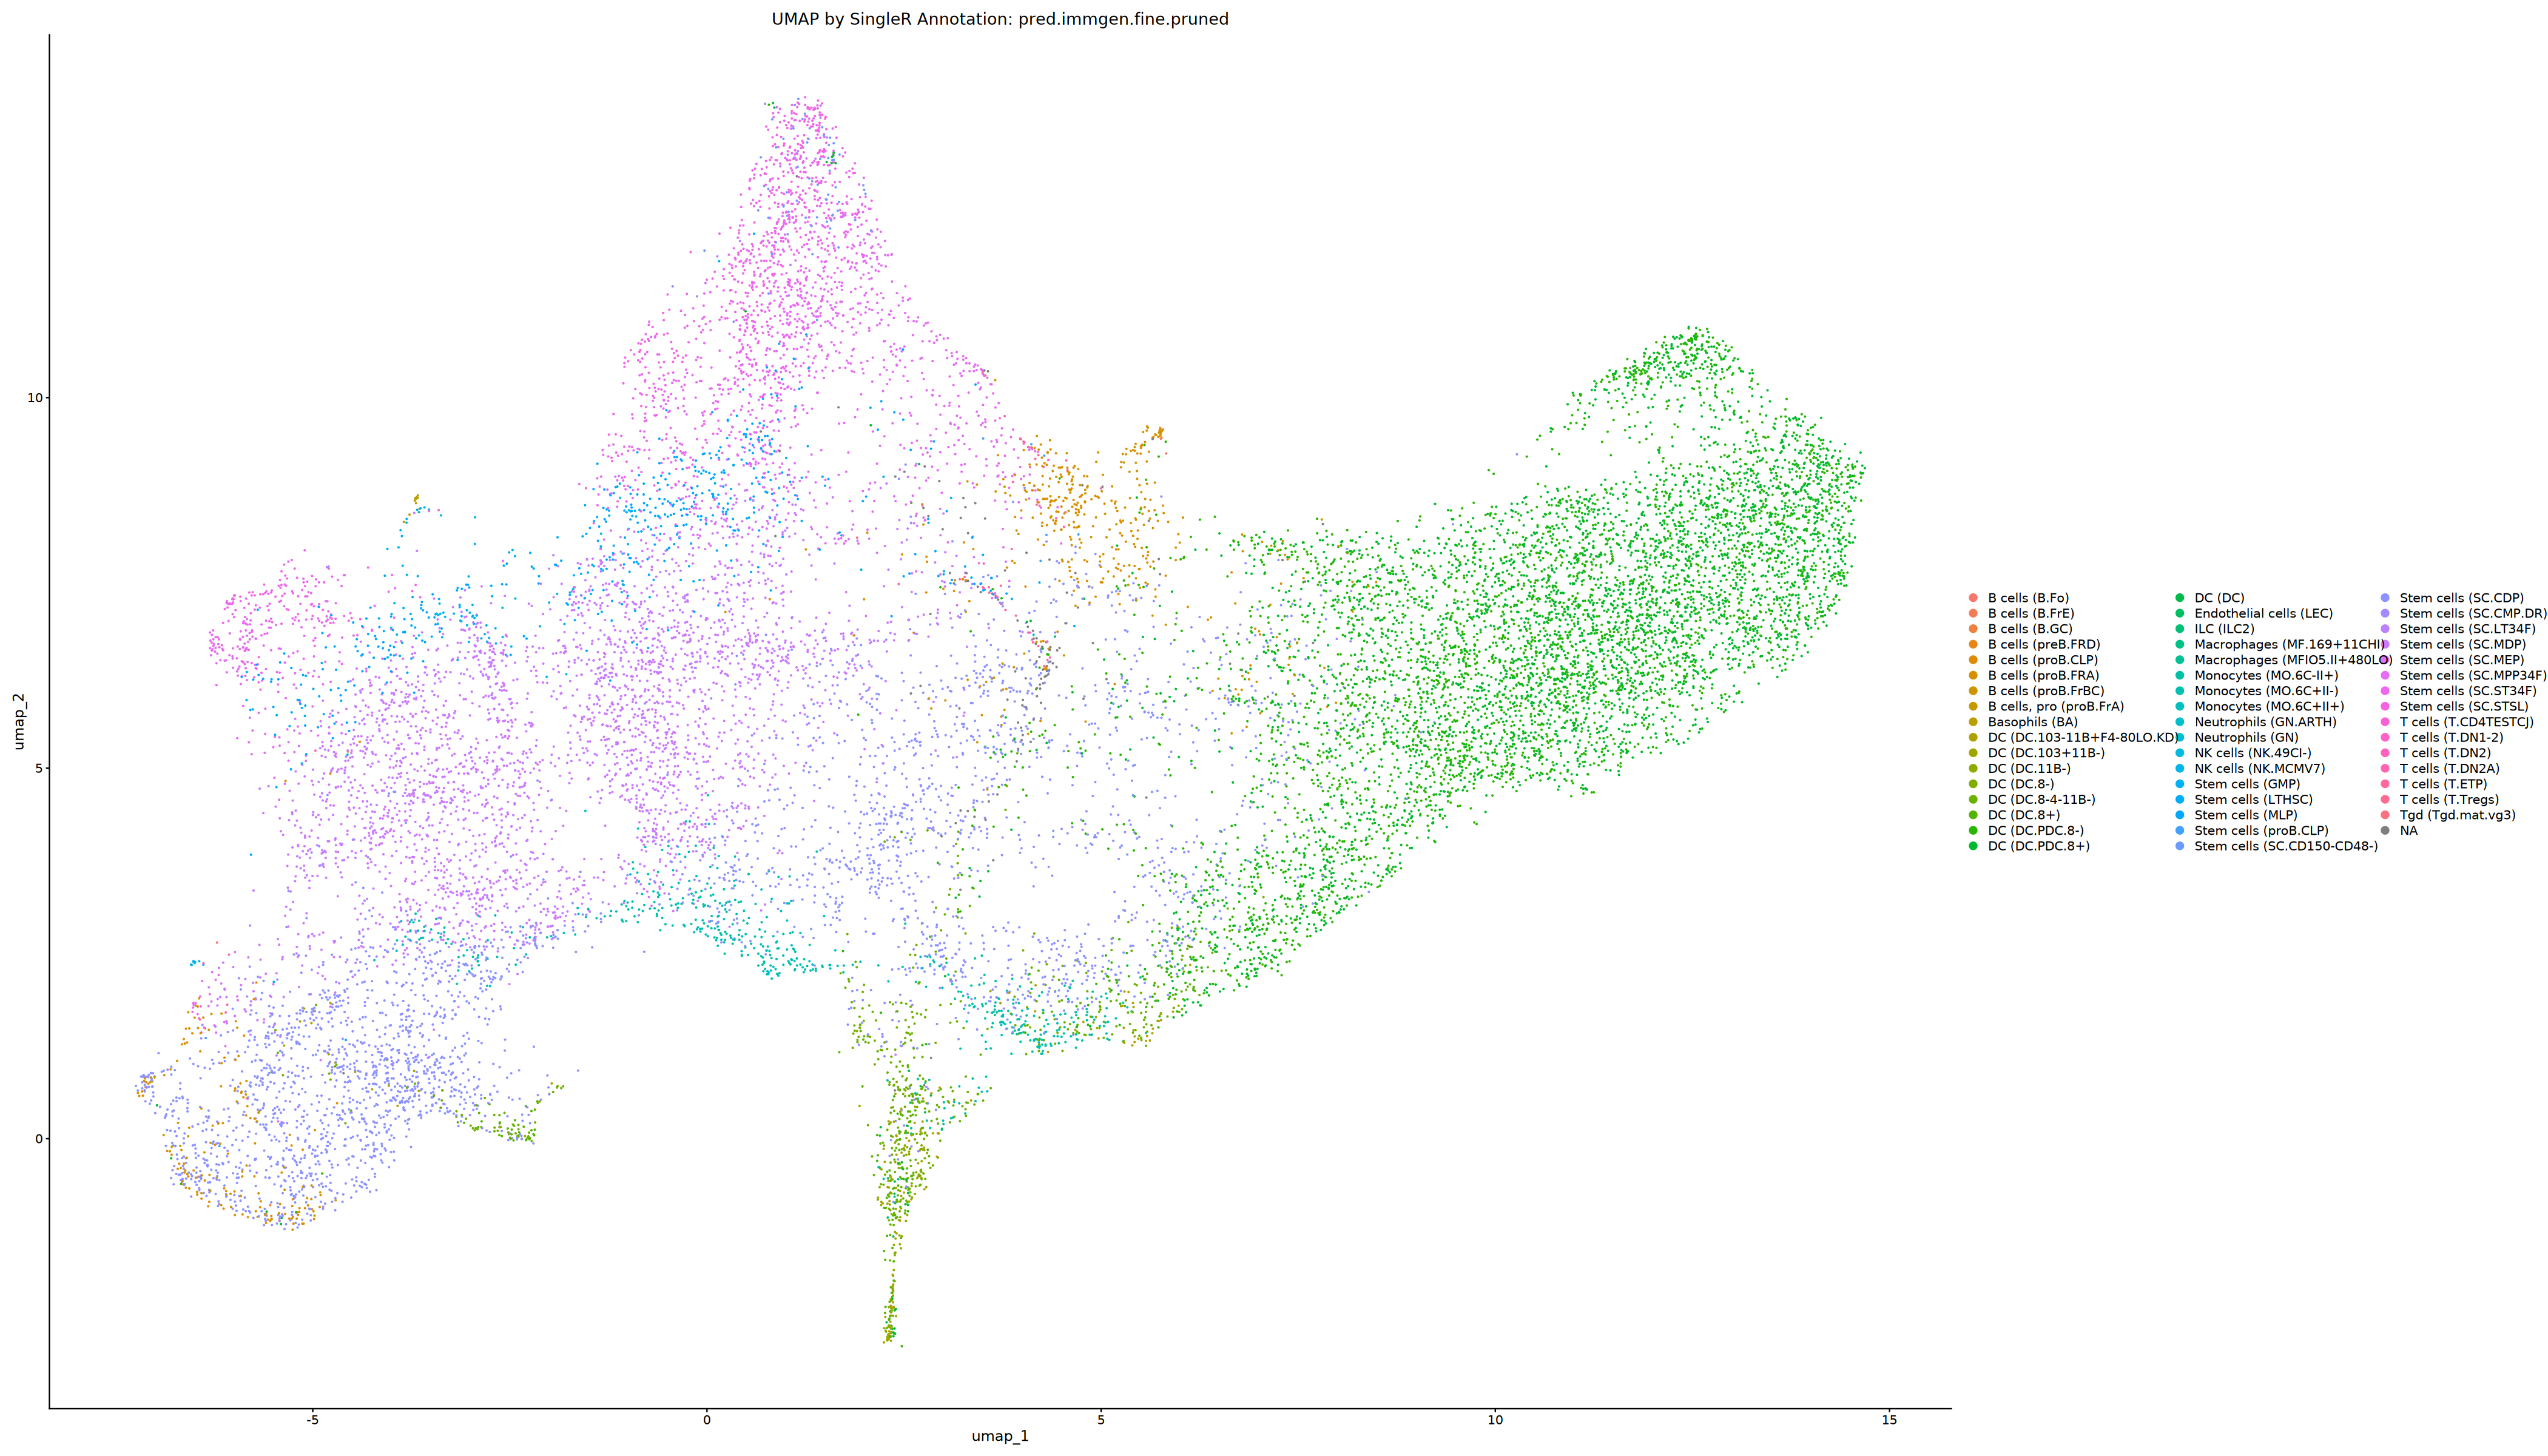

In [2]:
# ------------------- 5. 可视化SingleR注释结果 -------------------
# 指定用于可视化的注释列
annotation_to_visualize <- "pred.immgen.fine.pruned"

# 设置Jupyter Notebook中repr绘图的输出尺寸 (根据用户反馈的成功配置)
options(repr.plot.width = 35, repr.plot.height = 20)

# 检查UMAP降维结果和注释列是否存在
if ("umap" %in% names(singlet_data@reductions) &&
    annotation_to_visualize %in% colnames(singlet_data@meta.data)) {
    # 生成并打印SingleR注释的UMAP图
    plot_singler_umap <- DimPlot(singlet_data,
                                 reduction = "umap",
                                 group.by = annotation_to_visualize,
                                 label = FALSE,       # 关闭细胞标签，因为类别可能很多且导致viewport问题
                                 pt.size = 0.1) +     # 设置点的大小
                           theme(legend.position = "right") + # 图例放在右侧
                           ggtitle(paste("UMAP by SingleR Annotation:", annotation_to_visualize))
    print(plot_singler_umap) # 在Jupyter中，这会显示图像
} else {
    # 如果缺少必要信息，则打印警告
    missing_info <- c()
    if (!("umap" %in% names(singlet_data@reductions))) missing_info <- c(missing_info, "UMAP降维结果")
    if (!(annotation_to_visualize %in% colnames(singlet_data@meta.data))) missing_info <- c(missing_info, paste("注释列 '", annotation_to_visualize, "'", sep=""))
    warning(paste("无法生成SingleR注释的UMAP图，缺少:", paste(missing_info, collapse=" 和 ")))
}

In [3]:
if (!exists("singlet_data") || !("pred.immgen.fine.pruned" %in% colnames(singlet_data@meta.data))) {
    stop("错误: 'singlet_data' 对象或其元数据列 'pred.immgen.fine.pruned' 不存在。")
}

unique_cell_types <- sort(unique(stats::na.omit(singlet_data$pred.immgen.fine.pruned)))
num_unique_cell_types <- length(unique_cell_types)

items_per_line <- 5
for (i in seq_along(unique_cell_types)) {
    cat(sprintf("%-40s", unique_cell_types[i])) # %-40s 表示左对齐，宽度40
    if (i %% items_per_line == 0 || i == num_unique_cell_types) {
        cat("\n") # 每5个换行，或者在最后一个元素后换行
    } else {
        cat(" | ") # 分隔符
    }
}
# 如果最后一行没有满 items_per_line，确保也换行了
if (num_unique_cell_types %% items_per_line != 0 && num_unique_cell_types > 0) {
    # cat("\n") # 上面的逻辑已经包含了最后一个元素的换行
}

B cells (B.Fo)                           | B cells (B.FrE)                          | B cells (B.GC)                           | B cells (preB.FRD)                       | B cells (proB.CLP)                      
B cells (proB.FRA)                       | B cells (proB.FrBC)                      | B cells, pro (proB.FrA)                  | Basophils (BA)                           | DC (DC.103-11B+F4-80LO.KD)              
DC (DC.103+11B-)                         | DC (DC.11B-)                             | DC (DC.8-)                               | DC (DC.8-4-11B-)                         | DC (DC.8+)                              
DC (DC.PDC.8-)                           | DC (DC.PDC.8+)                           | DC (DC)                                  | Endothelial cells (LEC)                  | ILC (ILC2)                              
Macrophages (MF.169+11CHI)               | Macrophages (MFIO5.II+480LO)             | Monocytes (MO.6C-II+)                    | Monocytes (MO.6C+II

NULL

In [5]:
# =========================================================================
# ========= 单元格：计算和可视化细胞类型比例 =========
# =========================================================================
# 这个单元格依赖于上一个单元格成功运行并将SingleR注释添加到 singlet_data 对象

# 0. 检查必需的对象和列是否存在
print("--- 0. 检查必需的对象和列 ---")
if (!exists("singlet_data")) {
    stop("错误: 'singlet_data' Seurat 对象不存在。请确保之前的SingleR注释步骤已成功运行。")
}

# 定义用于比例计算和可视化的列名
# *** 请根据你的 Seurat 对象中的实际列名进行调整 ***
annotation_col_name <- "pred.immgen.fine.pruned" # SingleR 修剪后的注释列
cluster_col_name <- "seurat_clusters"      # 你的聚类结果列 (例如, seurat_clusters, RNA_snn_res.0.8 等)
condition_col_name <- "orig.ident"         # 区分样本/条件的列 (例如, WT, KO)

# 检查这些列是否存在于 singlet_data@meta.data 中
required_meta_cols <- c(annotation_col_name, cluster_col_name, condition_col_name)
missing_meta_cols <- setdiff(required_meta_cols, colnames(singlet_data@meta.data))
if (length(missing_meta_cols) > 0) {
    stop(paste("错误: 'singlet_data@meta.data' 中缺少以下必需的列:",
               paste(missing_meta_cols, collapse=", "),
               ". 请检查变量 'annotation_col_name', 'cluster_col_name', 'condition_col_name' 的设置。",
               "确保它们对应 Seurat 对象中的有效元数据列。可用列:",
               paste(head(colnames(singlet_data@meta.data)), collapse=", "), "..."))
}
print("必需的元数据列检查通过。")

# 1. 计算每个 Cluster 和 Condition 内每种 CellType 的细胞数和比例
print("--- 1. 计算细胞类型比例 ---")
# 从 Seurat 对象中提取必要的元数据
meta_data_for_proportions <- singlet_data@meta.data %>%
    select(
        Condition = all_of(condition_col_name),
        Cluster = all_of(cluster_col_name),
        CellType = all_of(annotation_col_name)
    )

# 计算每个 (Condition, Cluster, CellType) 组合的细胞数
cell_counts <- meta_data_for_proportions %>%
    count(Condition, Cluster, CellType, name = "N_CellType_In_Cluster_Condition")

# 计算每个 (Condition, Cluster) 组合的总细胞数
total_cells_in_cluster_condition <- meta_data_for_proportions %>%
    count(Condition, Cluster, name = "N_Total_In_Cluster_Condition")

# 合并计数并计算比例
# summary_df 将是这个单元格的主要输出，用于后续的CSV保存
summary_df <- left_join(cell_counts, total_cells_in_cluster_condition, by = c("Condition", "Cluster")) %>%
    mutate(proportion = N_CellType_In_Cluster_Condition / N_Total_In_Cluster_Condition) %>%
    select(Condition, Cluster, CellType, proportion, N_CellType_In_Cluster_Condition, N_Total_In_Cluster_Condition) %>%
    arrange(Condition, Cluster, desc(proportion)) # 按比例降序排列

print("细胞类型比例计算完成。summary_df 前几行:")
print(head(summary_df))

# 2. 准备用于显示和保存的数据框 (与你之前提供的代码逻辑一致)
print("--- 2. 准备用于显示和CSV保存的数据框 ---")
proportions_to_display <- summary_df %>%
    # 这里我们已经有了正确的列名 (Condition, Cluster, CellType, proportion)
    # 所以不需要再次 select 和 rename
    mutate(Proportion_Percent = paste0(round(proportion * 100, 1), "%")) %>%
    # 按 Condition, Cluster, 然后按 Proportion 降序排列，方便查看最重要的类型
    arrange(Condition, Cluster, desc(proportion)) # 这一步在 summary_df 创建时已做，但再次确认无妨

# 在保存前，选择需要的列，并移除原始的 "proportion" 数值列 (如果CSV中只需要百分比)
proportions_for_csv <- proportions_to_display %>%
    select(Condition, Cluster, CellType, Proportion_Percent, N_CellType_In_Cluster_Condition, N_Total_In_Cluster_Condition)

print("proportions_for_csv 前几行:")
print(head(proportions_for_csv))

# 3. 将数据保存到CSV文件
output_csv_dir <- legacy_path("20250519KO-GLH/2-anno-KO") # ** 修改为KO项目的路径 **
if (!dir.exists(output_csv_dir)) {
    message(paste("输出目录不存在，尝试创建:", output_csv_dir))
    dir.create(output_csv_dir, recursive = TRUE, showWarnings = TRUE)
}
output_csv_filename <- "singleR_proportions.csv" # 给一个有意义的文件名
output_csv_path <- file.path(output_csv_dir, output_csv_filename)

print(paste("将比例数据保存到CSV文件:", output_csv_path))
tryCatch({
    write.csv(proportions_for_csv, file = output_csv_path, row.names = FALSE, quote = TRUE)
    print("CSV文件保存成功。")
}, error = function(e) {
    stop(paste("错误: 无法将数据写入CSV文件 '", output_csv_path, "'. 错误信息: ", conditionMessage(e)))
})

[1] "--- 0. 检查必需的对象和列 ---"


[1] "必需的元数据列检查通过。"
[1] "--- 1. 计算细胞类型比例 ---"
[1] "细胞类型比例计算完成。summary_df 前几行:"
  Condition Cluster            CellType proportion
1        KO       0      DC (DC.PDC.8+) 0.59241245
2        KO       0      DC (DC.PDC.8-) 0.40758755
3        KO       1      DC (DC.PDC.8+) 0.70711974
4        KO       1      DC (DC.PDC.8-) 0.29288026
5        KO       2 Stem cells (SC.MDP) 0.84936709
6        KO       2    Stem cells (MLP) 0.04936709
  N_CellType_In_Cluster_Condition N_Total_In_Cluster_Condition
1                             609                         1028
2                             419                         1028
3                             437                          618
4                             181                          618
5                             671                          790
6                              39                          790
[1] "--- 2. 准备用于显示和CSV保存的数据框 ---"
[1] "proportions_for_csv 前几行:"
  Condition Cluster            CellType Proportion_Percent


[1] "--- 0. 检查必需的对象 ---"
[1] "--- 1. 生成细胞类型比例条形图 ---"
[1] "显示条形图..."
[1] "--- 可视化完成 ---"


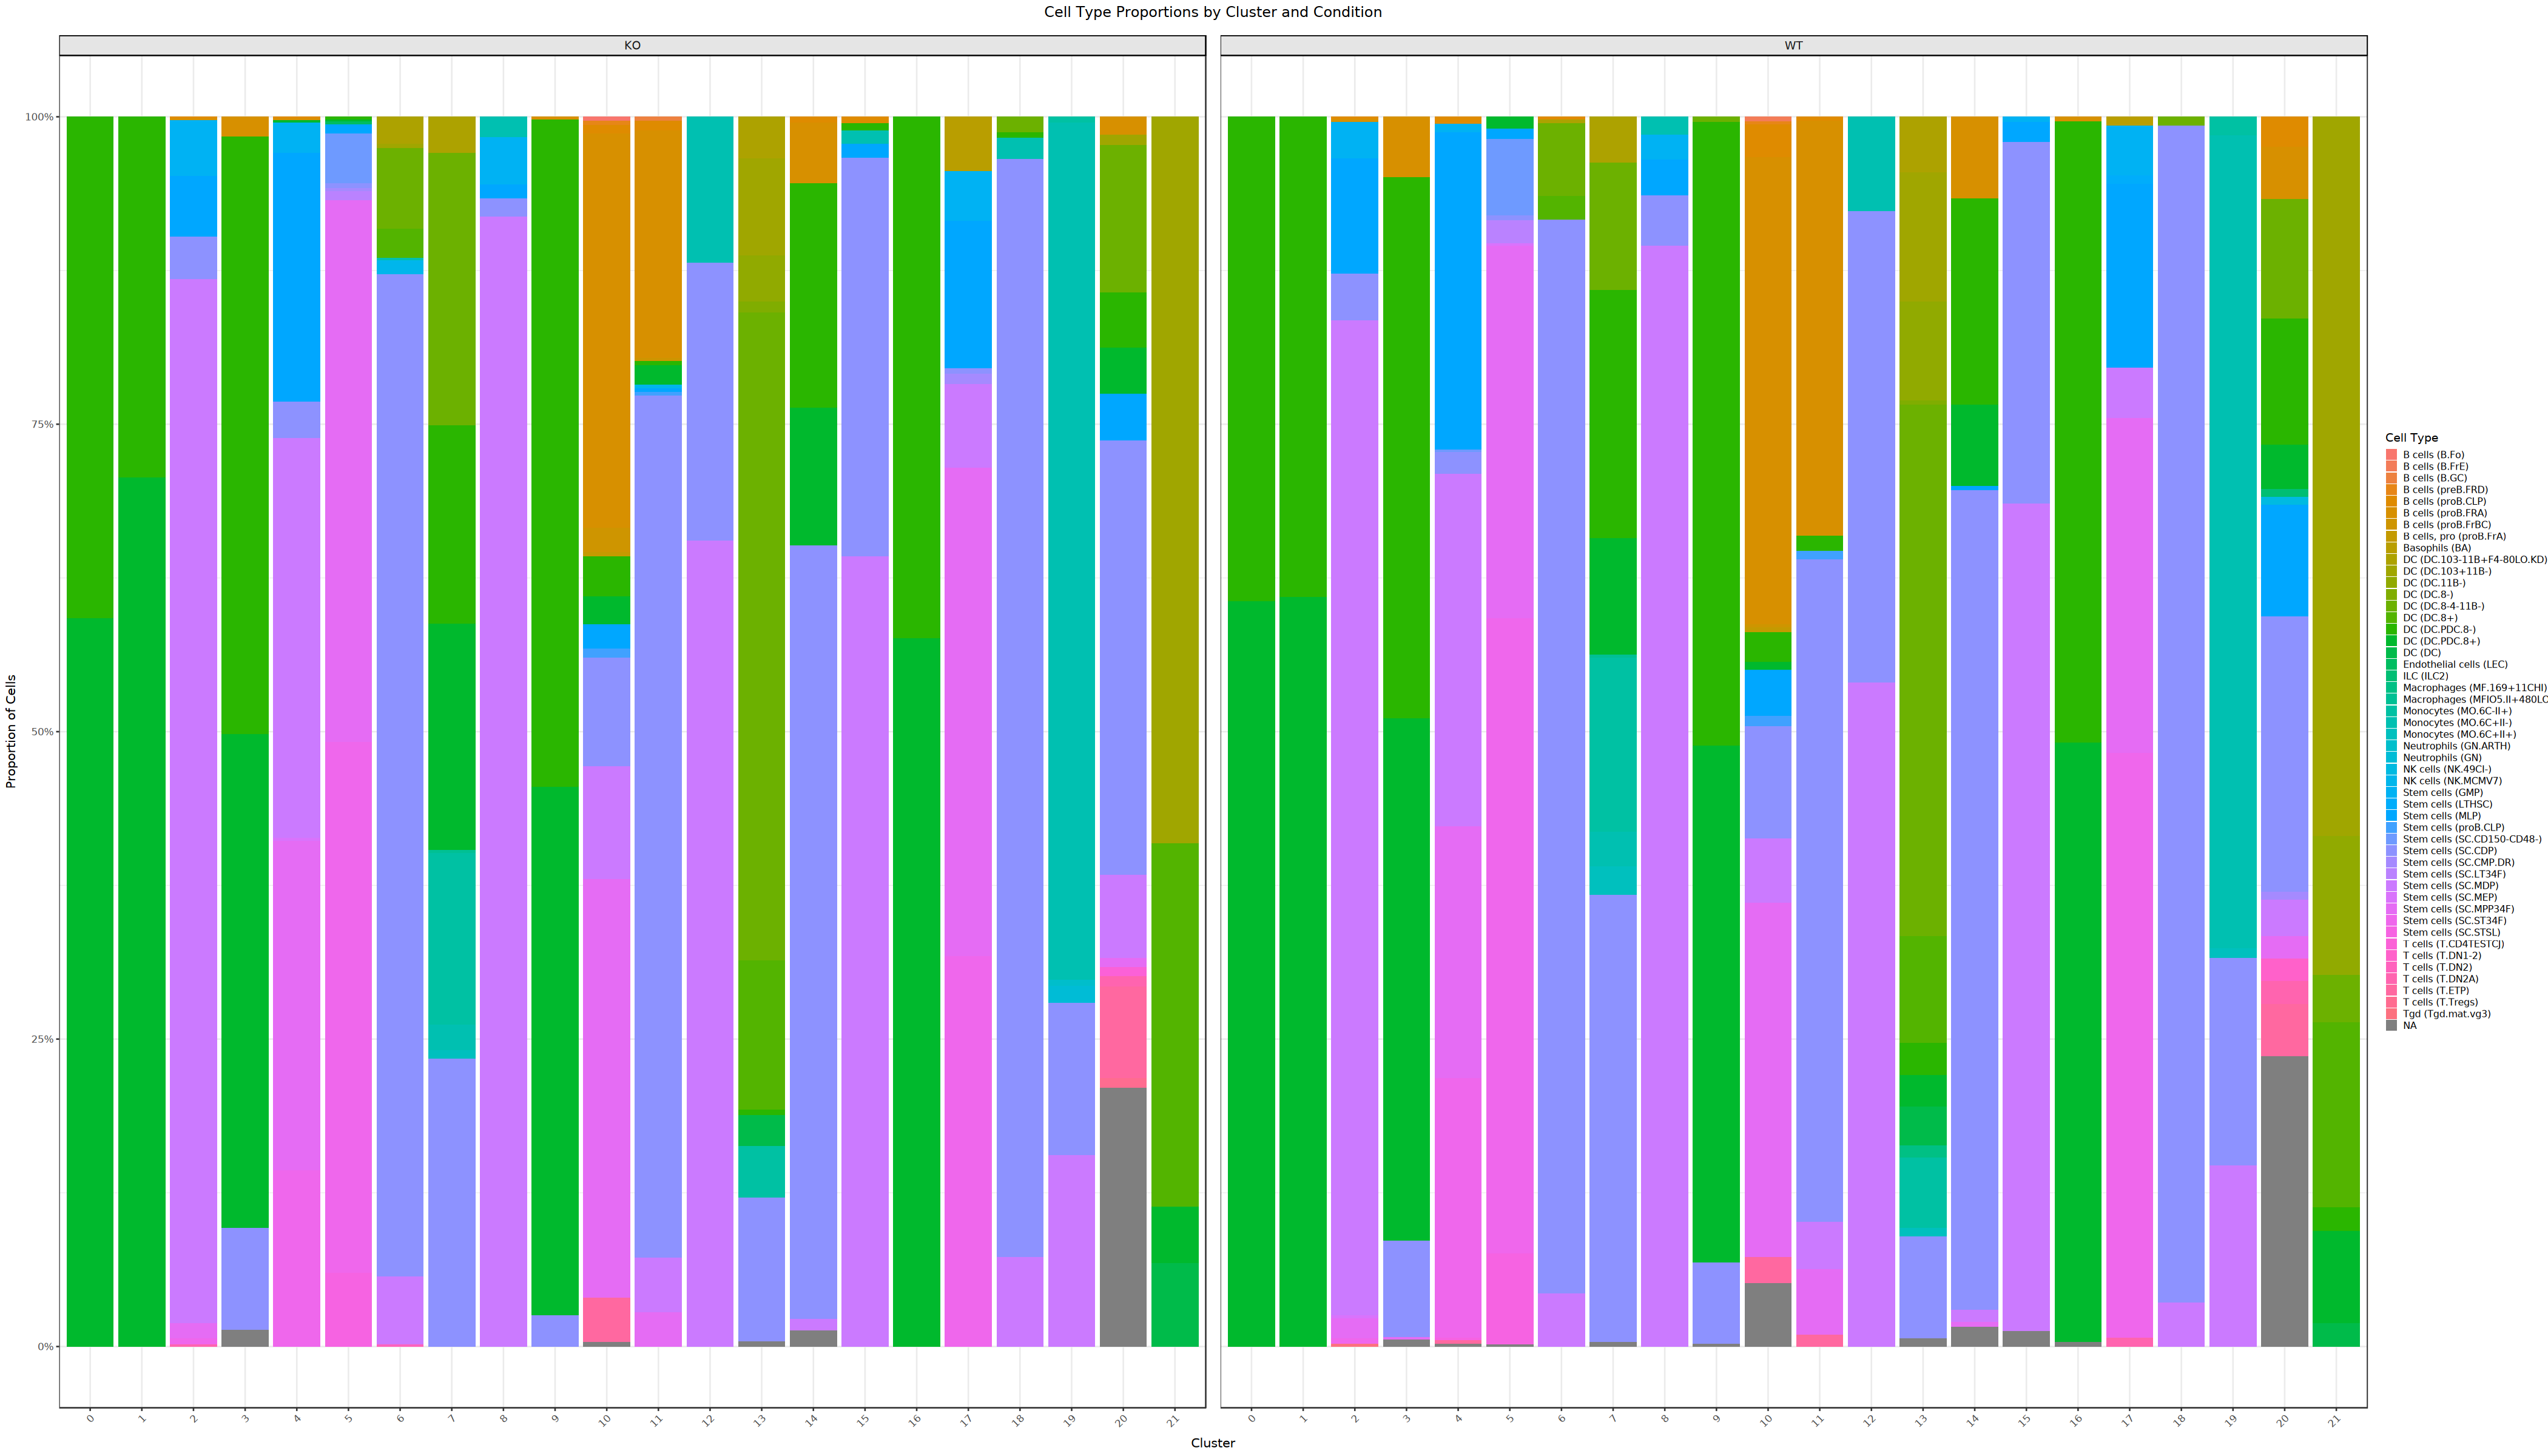

In [6]:
# =========================================================================
# ========= 单元格：可视化细胞类型比例条形图 =========
# =========================================================================
# 这个单元格依赖于上一个单元格成功运行并创建了 summary_df 对象

# 0. 检查必需的对象是否存在
print("--- 0. 检查必需的对象 ---")
if (!exists("summary_df")) {
    stop("错误: 'summary_df' 对象 (包含细胞类型比例) 不存在。请确保之前的比例计算步骤已成功运行。")
}
if (!all(c("Condition", "Cluster", "CellType", "proportion") %in% colnames(summary_df))) {
    stop("错误: 'summary_df' 对象缺少必需的列: 'Condition', 'Cluster', 'CellType', 'proportion'.")
}

# 1. 加载绘图包 (如果尚未加载)
# suppressPackageStartupMessages({ # 如果在脚本顶部已加载，这里可以省略
#     library(ggplot2)
#     library(RColorBrewer) # 可选，用于更多颜色选择
#     library(dplyr)      # summary_df 的处理可能已用到
# })

# 2. 生成条形图
print("--- 1. 生成细胞类型比例条形图 ---")

# 为了更好的可视化，可能需要确保Cluster是因子类型，并且按数字顺序排列 (如果它是数字)
# (如果Cluster已经是字符型且顺序是你想要的，则可以跳过)
if (is.numeric(summary_df$Cluster) || all(!is.na(as.numeric(as.character(summary_df$Cluster))))) {
    summary_df_for_plot <- summary_df %>%
        mutate(Cluster = factor(Cluster, levels = sort(unique(as.numeric(as.character(Cluster))))))
} else {
    summary_df_for_plot <- summary_df %>%
        mutate(Cluster = factor(Cluster)) # 如果是字符型，直接转因子
}

# 获取细胞类型的数量，用于颜色分配
num_cell_types <- length(unique(summary_df_for_plot$CellType))

# 选择一个调色板
# 如果细胞类型过多，默认颜色可能不够，可以考虑使用 RColorBrewer
# 例如: color_palette <- colorRampPalette(brewer.pal(9, "Set1"))(num_cell_types)
# 这里使用ggplot2的默认调色板，如果类型不多，效果尚可

p_barplot <- ggplot(summary_df_for_plot, aes(x = Cluster, y = proportion, fill = CellType)) +
    geom_bar(stat = "identity", position = "stack") + # 堆叠条形图
    # 按 Condition 分面，每种 Condition 一个图
    # scales = "free_x" 允许不同分面的x轴独立（如果Cluster在不同Condition下不同）
    facet_wrap(~ Condition, scales = "free_x", ncol = length(unique(summary_df_for_plot$Condition))) +
    scale_y_continuous(labels = scales::percent_format(accuracy = 1), name = "Proportion of Cells") + # Y轴显示百分比
    labs(
        title = "Cell Type Proportions by Cluster and Condition",
        x = "Cluster",
        fill = "Cell Type" # 图例标题
    ) +
    theme_bw(base_size = 12) + # 使用黑白主题，调整基础字体大小
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10), # X轴标签倾斜
        axis.title.x = element_text(size = 12, margin = margin(t = 10)),
        axis.title.y = element_text(size = 12, margin = margin(r = 10)),
        strip.background = element_rect(fill="grey90", colour = "black"), # 分面标签背景
        strip.text = element_text(size = 11, face = "bold"),              # 分面标签文字
        plot.title = element_text(size = 14, hjust = 0.5, face = "bold", margin = margin(b=15)), # 图标题
        legend.title = element_text(size = 11, face="bold"),
        legend.text = element_text(size = 9),
        legend.position = "right", # 图例位置
        panel.spacing = unit(1, "lines") # 分面之间的间距
    )

# (可选) 如果颜色太多导致图例拥挤，可以调整图例
if (num_cell_types > 15) { # 如果细胞类型超过15种，图例可能很长
    p_barplot <- p_barplot + guides(fill = guide_legend(ncol = 1, keywidth = 0.8, keyheight = 0.8, title.position = "top"))
}


# 3. 直接在R环境中显示图形
print("显示条形图...")
print(p_barplot)

print("--- 可视化完成 ---")

In [7]:
print(names(singlet_data@meta.data))

 [1] "orig.ident"              "nCount_RNA"             
 [3] "nFeature_RNA"            "percent.mt"             
 [5] "RNA_snn_res.0.5"         "seurat_clusters"        
 [7] "doublet"                 "pANN"                   
 [9] "RNA_snn_res.0.1"         "RNA_snn_res.0.2"        
[11] "RNA_snn_res.0.3"         "RNA_snn_res.0.4"        
[13] "RNA_snn_res.0.6"         "RNA_snn_res.0.7"        
[15] "RNA_snn_res.0.8"         "RNA_snn_res.0.9"        
[17] "RNA_snn_res.1"           "RNA_snn_res.1.1"        
[19] "RNA_snn_res.1.2"         "pred.immgen.fine"       
[21] "pred.immgen.fine.pruned"
